In [1]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime


def wf_model(N, n, phi, t, replicates = 10, seed = None):
    """
    Wright–Fisher model with geneic selection.

    Parameters
    ----------
    N : int
        Diploid population size.
    n : int
        Initial number of copies of the allele (0..2N).
    phi : float
        Fitness multiplier for the allele.
        phi > 1 favors the allele; phi < 1 disfavors it.
    t : int
        Number of generations to simulate.
    replicates : int
        Number of independent simulation replicates.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    freqs : np.ndarray
        Array of shape (replicates, t+1) with allele frequencies per generation.
    """
    rng = np.random.default_rng(seed)
    total_copies = 2 * N

    freqs = np.empty((replicates, t + 1), dtype = float)
    counts = np.full(replicates, n, dtype = int)
    freqs[:, 0] = counts / total_copies     # initial frequencies

    for generation in range(t):
        p = counts / total_copies
        # Selection step (genic): p' = (p*phi) / (p*phi + (1-p))
        denom = p * phi + (1.0 - p)
        denom = np.where(denom <= 0.0, 1e-12, denom)  # Avoid division by zero
        p_sel = (p * phi) / denom
        p_sel = np.clip(p_sel, 0.0, 1.0)              # Probabilities in [0,1]

        counts = rng.binomial(total_copies, p_sel)
        freqs[:, generation + 1] = counts / total_copies

    return freqs

In [4]:
seed = 42
N = 2
replicates = 10

rng = np.random.default_rng(seed)
print(f"RNG: {rng}")

total_copies = 2 * N
print(f"N = {N}")

freqs = np.empty((replicates, t + 1), dtype = float)
counts = np.full(replicates, n, dtype = int)
print(f"Counts: {counts}")

freqs[:, 0] = counts / total_copies     # initial frequencies
print(f"Frequencies: {freqs}")

# for generation in range(t):
#     p = counts / total_copies
#     # Selection step (genic): p' = (p*phi) / (p*phi + (1-p))
#     denom = p * phi + (1.0 - p)
#     denom = np.where(denom <= 0.0, 1e-12, denom)  # Avoid division by zero
#     p_sel = (p * phi) / denom
#     p_sel = np.clip(p_sel, 0.0, 1.0)              # Probabilities in [0,1]

#     counts = rng.binomial(total_copies, p_sel)
#     freqs[:, generation + 1] = counts / total_copies

RNG: Generator(PCG64)
N = 2


NameError: name 't' is not defined

[[0.5    0.5205 0.515  0.517  0.5175 0.523  0.5185 0.5435 0.5335 0.536
  0.548  0.555  0.555  0.5325 0.52   0.5065 0.5115 0.506  0.5045 0.482
  0.482 ]
 [0.5    0.503  0.505  0.514  0.523  0.5385 0.5315 0.553  0.5695 0.557
  0.554  0.5535 0.555  0.569  0.58   0.557  0.5705 0.575  0.5665 0.5805
  0.568 ]
 [0.5    0.487  0.474  0.4825 0.485  0.49   0.472  0.466  0.4725 0.484
  0.49   0.4915 0.488  0.4675 0.469  0.477  0.4735 0.4945 0.491  0.449
  0.4495]
 [0.5    0.518  0.54   0.5505 0.5435 0.5355 0.562  0.545  0.559  0.574
  0.585  0.5845 0.5755 0.57   0.574  0.5595 0.561  0.5625 0.5715 0.559
  0.561 ]
 [0.5    0.511  0.5135 0.515  0.5325 0.5275 0.5215 0.5175 0.5325 0.5315
  0.5245 0.5245 0.5305 0.534  0.5265 0.5395 0.534  0.532  0.5325 0.541
  0.5345]
 [0.5    0.4975 0.486  0.494  0.485  0.4815 0.483  0.4705 0.4685 0.4965
  0.4925 0.483  0.4515 0.4505 0.4495 0.4225 0.414  0.4025 0.4015 0.398
  0.4215]
 [0.5    0.519  0.529  0.517  0.527  0.5075 0.505  0.511  0.5215 0.5285
  0.5495 0.55

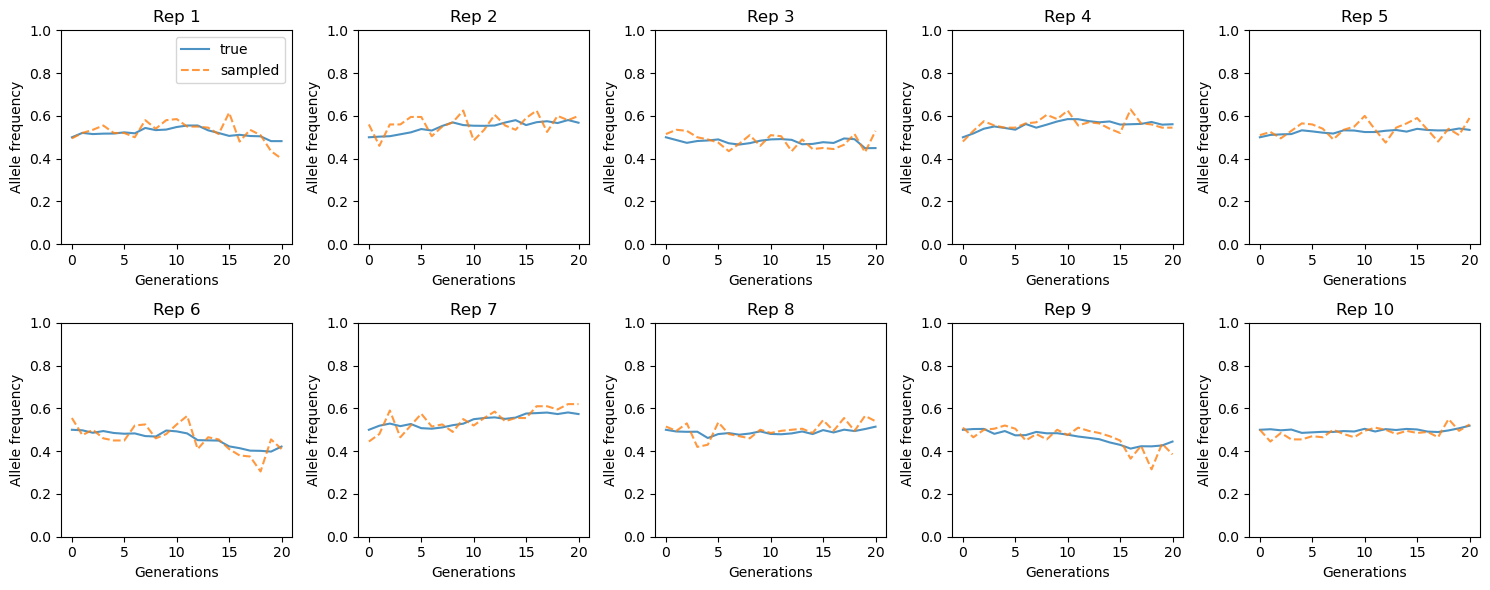

In [6]:
def hypergeometric_sampling(N, freqs_T, S = None, seed = None):
    """ 
    Sample allele counts without replacement at each [generation, replicate]
    using a hypergeometric draw, then convert to sampled frequencies.

    Parameters
    ----------
    N : int
        Diploid population size (defines population copies M = 2N).
    freqs_T : np.ndarray
        True frequencies with shape (t+1, replicates)  [rows = generations, columns = replicates].
    S : int or None
        Sample size (number of chromosomes sampled). 
        If None: S = int(0.2 * N)
    seed : int or None
        RNG seed.

    Returns
    -------
    freqs_sampled_T : np.ndarray
        Sampled frequencies with same shape as freqs_T.
    """
    rng = np.random.default_rng(seed)
    M = 2 * N

    if S is None:
        S = int(0.2 * N)
    S = int(max(1, min(S, M)))  # clamp to [1, 2N]

    # convert true frequencies to integer counts in [0, M]
    K = np.rint(freqs_T * M).astype(int)  
    K = np.clip(K, 0, M) 

    # X ~ Hypergeom(ngood = K, nbad = M-K, nsample = S)
    X = rng.hypergeometric(ngood = K, nbad = M - K, nsample = S)

    freqs_sampled_T = X / S
    return freqs_sampled_T
    
def plot_trajectories(generations, freqs_T, freqs_sampled_T):
    """
    Plot true vs sampled allele frequency trajectories (for quick visual QC).

    Parameters
    ----------
    generations : np.ndarray
        Array of generation indices.
    freqs_T : np.ndarray
        True frequencies with shape (t+1, replicates).
    freqs_sampled_T : np.ndarray
        Sampled frequencies with same shape as freqs_T.
    """
    k = freqs_T.shape[1]                  # number of replicates (columns)
    rows, cols = 2, 5                     # grid for up to 10 replicates
    fig, axes = plt.subplots(rows, cols, figsize=(15, 6), sharex=False, sharey=False)
    axes = axes.ravel()

    for idx in range(min(k, rows * cols)):
        axes[idx].plot(generations, freqs_T[:, idx], label="true", alpha=0.8)
        axes[idx].plot(generations, freqs_sampled_T[:, idx], label="sampled", ls="--", alpha=0.8)
        axes[idx].set_title(f"Rep {idx+1}")
        axes[idx].set_ylim(0, 1.0)        # allele freq in [0,1]
        axes[idx].set_xlabel("Generations")
        axes[idx].set_ylabel("Allele frequency")
        if idx == 0:
            axes[idx].legend()

    # hide unused subplots if k < rows*cols
    for ax in axes[k:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

N = 1000        # diploid population size
n = N           # initial copies (=> p0 = n/(2N) = 0.5)
phi = 1         # Fitness coefficient (>1 favors the allele; <1 disfavors it)
t = 20          # generations
reps = 10       # number of replicate trajectories

# ---- 1) simulate trajectories (true frequencies) ----
freqs = wf_model(N, n, phi, t, replicates = reps, seed = 123)
print(freqs)

# ---- 2) Transpose as rows = generations, cols = replicates ----
freqs_T = freqs.T

# ---- 3) hypergeometric sampling to mimic finite sampling ----
freqs_sampled_T = hypergeometric_sampling(N, freqs_T, S = None, seed = 456)

# ---- 4) plotting: true vs sampled ----
assert freqs_sampled_T.shape == freqs_T.shape
assert (freqs_sampled_T >= 0).all() and (freqs_sampled_T <= 1).all()

generations = np.arange(t + 1)
plot_trajectories(generations, freqs_T, freqs_sampled_T)
